In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

In [2]:
dat = gpd.read_file('reviews_demog_2010.gpkg')

In [3]:
dat['text'] = dat.text.str.lower()
dat = dat.dropna(subset=['text', 'gentrified']).reset_index(drop=True)

In [4]:
from sklearn.feature_extraction.text import CountVectorizer
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
import re

# 1. Setup (assuming 'undf' is a DataFrame)
# corpus_undf <- corpus(undf, text_field = "text")
texts = dat['text']

# 2. Preprocessing Function (tokens, remove_punct, remove_numbers, wordstem)
stemmer = SnowballStemmer("english")
stop_words = set(stopwords.words('english'))

def preprocess(text):
    # remove_punct and remove_numbers using regex
    #text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # tokens_wordstem and stopwords remove
    tokens = [stemmer.stem(word) for word in text.split() if word not in stop_words]
    return " ".join(tokens)

# Apply preprocessing
processed_texts = texts.apply(preprocess)

# 3. Create DFM (Document-Feature Matrix)
# dfm <- dfm(toks)
vectorizer = CountVectorizer()
dfm = vectorizer.fit_transform(processed_texts)

# 4. Trim DFM (min_docfreq = 0.05)
# dfm_trim(dfm, min_docfreq = 0.05, docfreq_type = "prop")
trimmed_vectorizer = CountVectorizer(min_df=0.05)
dfm_trimmed = trimmed_vectorizer.fit_transform(processed_texts)

# Convert to DataFrame for viewing (optional)
dfm_trimmed_df = pd.DataFrame(
    dfm_trimmed.toarray(), 
    columns=trimmed_vectorizer.get_feature_names_out()
)

print(dfm_trimmed_df)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ellabartt/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


        actual  also  alway  amaz  anoth  appet  area  around  ask  atmospher  \
0            0     0      0     0      0      0     1       0    0          0   
1            0     0      1     0      0      0     0       0    0          0   
2            0     1      1     0      0      0     0       0    0          0   
3            0     1      0     0      0      0     0       0    0          0   
4            0     0      0     0      0      0     0       0    0          0   
...        ...   ...    ...   ...    ...    ...   ...     ...  ...        ...   
677127       0     1      0     0      0      0     0       0    0          0   
677128       0     1      0     2      0      0     0       0    0          0   
677129       0     1      0     1      0      0     0       0    0          0   
677130       0     1      0     0      0      0     0       0    0          0   
677131       0     1      0     0      2      0     0       0    0          0   

        ...  wasnt  way  we

In [5]:
dat['id'] = dat.index

In [6]:
from sklearn.model_selection import train_test_split
training, validation = train_test_split(
    dat, 
    train_size=0.75, 
    random_state=32123
)


In [7]:
#Create separate subsets for DFM
dfmat_train = dfm_trimmed_df.loc[training.index]
dfmat_val = dfm_trimmed_df.loc[validation.index]
X_train = dfmat_train
X_test = dfmat_val
y_train = dat.loc[training.index].gentrified
y_test = dat.loc[validation.index].gentrified

In [8]:
dfmat_train

,actual,also,alway,amaz,anoth,appet,area,around,ask,atmospher,...,wasnt,way,week,well,went,work,worth,would,year,your
519793,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,1,0,1,0
133753,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
506968,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
438218,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
491453,0,0,0,1,0,0,0,1,2,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
529997,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,2,0,0
262968,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
241115,2,0,0,0,0,1,0,1,0,0,...,0,2,0,2,0,0,0,1,0,0
218058,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [9]:
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import confusion_matrix, classification_report

lasso_model = LogisticRegression(penalty='l1', solver = 'saga', random_state=4323, )
lasso_model.fit(X_train, y_train)

testing = []
for i, j in enumerate(X_train.columns):
    testing.append({
        'word': j,
        'rank': lasso_model.coef_[0][i],
        'rank_abs': np.abs(lasso_model.coef_[0][i])
    })
importance = pd.DataFrame(testing)
importance = importance.sort_values(by = 'rank', ascending = False)

# --- 4. Out of Sample Predictions ---
# Probability predictions (type="response")
pred_probs = lasso_model.predict_proba(X_test)[:, 1]

# Confusion Matrix (Table)
# Since R's index 40 or 1 refers to specific lambdas, in Python you'd just 
# predict using the fitted model or specific thresholds.
print(confusion_matrix(y_test, lasso_model.predict(X_test)))

confusion_matrix(y_test, lasso_model.predict(X_test))

[[153205     51]
 [ 16011     16]]


array([[153205,     51],
       [ 16011,     16]])

In [10]:
importance.sort_values(by = 'rank_abs', ascending = False).head(10)

,word,rank,rank_abs
16,beer,0.219276,0.219276
6,area,0.214978,0.214978
29,citi,-0.202774,0.202774
100,meat,0.185773,0.185773
39,dessert,-0.178179,0.178179
121,pizza,0.177316,0.177316
155,soup,-0.175340,0.175340
120,philli,-0.159360,0.159360
89,live,0.142340,0.142340
146,select,0.132319,0.132319


In [11]:
print(classification_report(y_test, lasso_model.predict(X_test)))

              precision    recall  f1-score   support

         0.0       0.91      1.00      0.95    153256
         1.0       0.24      0.00      0.00     16027

    accuracy                           0.91    169283
   macro avg       0.57      0.50      0.48    169283
weighted avg       0.84      0.91      0.86    169283



In [12]:
# --- 5. Cross-Validation (cv.glmnet) ---
# Cs is the number of inverse-lambdas to try
cv_model = LogisticRegressionCV(
    penalty='l1', 
    solver='saga', 
    cv=5, 
    scoring='accuracy', 
    class_weight='balanced' # Replaces manual weights
)
cv_model.fit(X_train, y_train)

testing2 = []
for i, j in enumerate(X_train.columns):
    testing2.append({
        'word': j,
        'rank': cv_model.coef_[0][i],
        'rank_abs': np.abs(cv_model.coef_[0][i])
    })
importance2 = pd.DataFrame(testing2)
importance2 = importance2.sort_values(by = 'rank', ascending = False)

pred_val = cv_model.predict(X_test)
tab_val = confusion_matrix(y_test, pred_val)
print("Final Validation Table:\n", tab_val)
importance2.head()

Final Validation Table:
 [[132859  20397]
 [ 12303   3724]]


,word,rank,rank_abs
121,pizza,0.068289,0.068289
16,beer,0.061913,0.061913
0,actual,0.000000,0.000000
125,portion,0.000000,0.000000
127,price,0.000000,0.000000


In [13]:
print(classification_report(y_test, cv_model.predict(X_test)))

              precision    recall  f1-score   support

         0.0       0.92      0.87      0.89    153256
         1.0       0.15      0.23      0.19     16027

    accuracy                           0.81    169283
   macro avg       0.53      0.55      0.54    169283
weighted avg       0.84      0.81      0.82    169283



In [14]:
importance2.tail()

,word,rank,rank_abs
69,get,0.0,0.0
70,give,0.0,0.0
71,go,0.0,0.0
72,good,0.0,0.0
197,your,0.0,0.0


In [15]:
import statsmodels.formula.api as smf

dat['authenticity'] = np.where(dat['text'].str.contains('authent'), 1, 0)
dat['beer'] = np.where(dat['text'].str.contains('beer'), 1, 0)
dat['simple'] = np.where(dat['text'].str.contains('simpl'), 1, 0)
dat['gentrified'] = dat['gentrified'].astype(int)
dat.columns


Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code_x',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours', 'neighborhood', 'gentrified',
       'review_id', 'user_id', 'useful', 'funny', 'cool', 'text', 'date',
       'TRACTCE', 'geographic_area_name', 'tot_pop', 'prop_black',
       'prop_asian', 'prop_hispanic_or_latino', 'prop_white_only',
       'overlap_area', 'prop_white_wavg', 'predom_poc', 'no_predom_race',
       'geometry', 'id', 'authenticity', 'beer', 'simple'],
      dtype='object')

In [16]:
authenticity_model = smf.logit('gentrified ~ authenticity', data=dat).fit()
print(authenticity_model.summary())

Optimization terminated successfully.
         Current function value: 0.313404
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             gentrified   No. Observations:               677132
Model:                          Logit   Df Residuals:                   677130
Method:                           MLE   Df Model:                            1
Date:                Fri, 08 May 2026   Pseudo R-squ.:               0.0001708
Time:                        10:21:04   Log-Likelihood:            -2.1222e+05
converged:                       True   LL-Null:                   -2.1225e+05
Covariance Type:            nonrobust   LLR p-value:                 1.681e-17
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -2.2509      0.004   -536.325      0.000      -2.259      -2.243
authenticity    -0.2301

In [17]:
beer_model = smf.logit('gentrified ~ beer', data=dat).fit()
print(beer_model.summary())

Optimization terminated successfully.
         Current function value: 0.311634
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             gentrified   No. Observations:               677132
Model:                          Logit   Df Residuals:                   677130
Method:                           MLE   Df Model:                            1
Date:                Fri, 08 May 2026   Pseudo R-squ.:                0.005819
Time:                        10:21:05   Log-Likelihood:            -2.1102e+05
converged:                       True   LL-Null:                   -2.1225e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.3257      0.004   -521.618      0.000      -2.334      -2.317
beer           0.6499      0.

In [18]:
simple_model = smf.logit('gentrified ~ simple', data=dat).fit()
print(simple_model.summary())

Optimization terminated successfully.
         Current function value: 0.313445
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             gentrified   No. Observations:               677132
Model:                          Logit   Df Residuals:                   677130
Method:                           MLE   Df Model:                            1
Date:                Fri, 08 May 2026   Pseudo R-squ.:               4.004e-05
Time:                        10:21:05   Log-Likelihood:            -2.1224e+05
converged:                       True   LL-Null:                   -2.1225e+05
Covariance Type:            nonrobust   LLR p-value:                 3.740e-05
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.2534      0.004   -534.181      0.000      -2.262      -2.245
simple        -0.0950      0.

## Using CV for models: scikit-learn

In [19]:
dat_grouped = dat.groupby('name').agg({'authenticity': 'sum', 'stars': 'mean', 'gentrified': 'mean'}).reset_index()
dat_grouped['gentrified'] = np.where(((dat_grouped['gentrified'] != 0) & (dat_grouped['gentrified'] != 1)), 0, dat_grouped['gentrified'])
dat_grouped['authentic'] = np.where(((dat_grouped['authenticity'] != 0) & (dat_grouped['authenticity'] != 1)), 1, dat_grouped['authenticity'])

In [20]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

X = dat[['authenticity']]
y = dat['gentrified']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12345)
auth_model_cv = LogisticRegressionCV(cv = 10, 
                                     random_state=12345, 
                                     #class_weight= 'balanced'
                                     ).fit(X_train, y_train)

# Get the best regularization parameter found
print(auth_model_cv.C_)
pred_auth = auth_model_cv.predict(X_test)
print(confusion_matrix(y_test, pred_auth))
print(auth_model_cv.coef_)      # Array of feature weights
print(auth_model_cv.intercept_) #
print(classification_report(y_test, pred_auth))

[0.0001]
[[122652      0]
 [ 12775      0]]
[[-0.01912416]]
[-2.25482394]
              precision    recall  f1-score   support

           0       0.91      1.00      0.95    122652
           1       0.00      0.00      0.00     12775

    accuracy                           0.91    135427
   macro avg       0.45      0.50      0.48    135427
weighted avg       0.82      0.91      0.86    135427



/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

In [21]:
X = dat[['authenticity', 'beer']]
y = dat['gentrified']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12345)
authbeer_model_cv = LogisticRegressionCV(cv = 10, 
                                     random_state=12345, 
                                     #class_weight= 'balanced'
                                     ).fit(X_train, y_train)

# Get the best regularization parameter found
print(authbeer_model_cv.C_)
pred_authbeer = authbeer_model_cv.predict(X_test)
print(confusion_matrix(y_test, pred_authbeer))
print(authbeer_model_cv.coef_)      # Array of feature weights
print(authbeer_model_cv.intercept_) #
print(classification_report(y_test, pred_authbeer))


[0.0001]
[[122652      0]
 [ 12775      0]]
[[-0.02017438  0.20800576]]
[-2.27369861]
              precision    recall  f1-score   support

           0       0.91      1.00      0.95    122652
           1       0.00      0.00      0.00     12775

    accuracy                           0.91    135427
   macro avg       0.45      0.50      0.48    135427
weighted avg       0.82      0.91      0.86    135427



/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

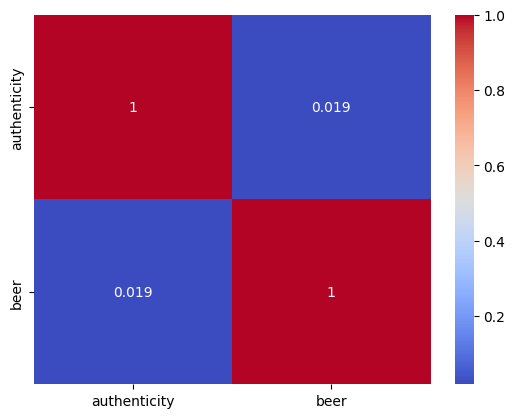

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix
corr_matrix = X.corr().abs()

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()


In [23]:
from sklearn.model_selection import permutation_test_score
from sklearn.datasets import make_classification

X, y = make_classification(random_state=12345)
estimator = LogisticRegressionCV()
score, permutation_scores, pvalue = permutation_test_score(
    estimator, X, y, random_state=12345
)
print(f"Original Score: {score:.3f}")
print(
    f"Permutation Scores: {permutation_scores.mean():.3f} +/- "
    f"{permutation_scores.std():.3f}"
)
print(f"P-value: {pvalue:.3f}")

Original Score: 0.850
Permutation Scores: 0.499 +/- 0.062
P-value: 0.010


In [24]:
##GROUPED BY BUSINESS

X = dat_grouped[['authenticity']]
y = dat_grouped['gentrified']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12345)
auth_model_cv_grp = LogisticRegressionCV(cv = 10, 
                                     random_state=12345, 
                                     #class_weight= 'balanced'
                                     ).fit(X_train, y_train)

# Get the best regularization parameter found
print(auth_model_cv_grp.C_)
pred_auth_grp = auth_model_cv_grp.predict(X_test)
print(confusion_matrix(y_test, pred_auth_grp))
print(auth_model_cv_grp.coef_)      # Array of feature weights
print(auth_model_cv_grp.intercept_) #
print(classification_report(y_test, pred_auth_grp))

[0.0001]
[[891   0]
 [101   0]]
[[-0.02096649]]
[-2.0814161]
              precision    recall  f1-score   support

         0.0       0.90      1.00      0.95       891
         1.0       0.00      0.00      0.00       101

    accuracy                           0.90       992
   macro avg       0.45      0.50      0.47       992
weighted avg       0.81      0.90      0.85       992



/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

In [25]:
X, y = make_classification(random_state=12345)
estimator = LogisticRegressionCV()
score, permutation_scores, pvalue = permutation_test_score(
    estimator, X, y, random_state=12345
)
print(f"Original Score: {score:.3f}")
print(
    f"Permutation Scores: {permutation_scores.mean():.3f} +/- "
    f"{permutation_scores.std():.3f}"
)
print(f"P-value: {pvalue:.3f}")

Original Score: 0.850
Permutation Scores: 0.499 +/- 0.062
P-value: 0.010


# Using demographic data with authenticity for gentrification pred

In [33]:
dat.predom_poc.value_counts()

predom_poc
0    513551
1    163581
Name: count, dtype: int64

In [45]:
X = dat[['authenticity', 'predom_poc']]
y = dat['gentrified']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12345)
authrace_model_cv = LogisticRegressionCV(cv = 10, 
                                     random_state=12345, 
                                     #class_weight= 'balanced'
                                     ).fit(X_train, y_train)

# Get the best regularization parameter found
print(authrace_model_cv.C_)
pred_authrace = authrace_model_cv.predict(X_test)
print(confusion_matrix(y_test, pred_authrace))
print(authrace_model_cv.coef_)      # Array of feature weights
print(authrace_model_cv.intercept_) #
print(classification_report(y_test, pred_authrace))

[0.0001]
[[122652      0]
 [ 12775      0]]
[[-0.01858975 -0.32273488]]
[-2.18422471]
              precision    recall  f1-score   support

           0       0.91      1.00      0.95    122652
           1       0.00      0.00      0.00     12775

    accuracy                           0.91    135427
   macro avg       0.45      0.50      0.48    135427
weighted avg       0.82      0.91      0.86    135427



/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

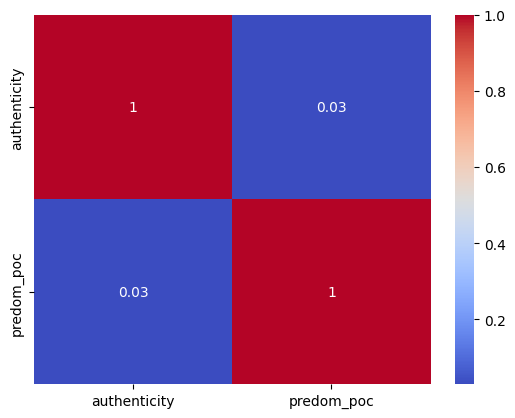

In [46]:
corr_matrix = X.corr().abs()

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [39]:
X, y = make_classification(random_state=12345)
estimator = LogisticRegressionCV()
score, permutation_scores, pvalue = permutation_test_score(
    estimator, X, y, random_state=12345
)
print(f"Original Score: {score:.3f}")
print(
    f"Permutation Scores: {permutation_scores.mean():.3f} +/- "
    f"{permutation_scores.std():.3f}"
)
print(f"P-value: {pvalue:.3f}")

Original Score: 0.850
Permutation Scores: 0.499 +/- 0.062
P-value: 0.010


In [43]:
dat_white_subset = dat[dat['predom_poc'] == 0]
dat_poc_subset = dat[dat['predom_poc'] == 1]

X_white = dat_white_subset[['authenticity']]
y_white = dat_white_subset['gentrified']

X_poc = dat_poc_subset[['authenticity']]
y_poc = dat_poc_subset['gentrified']

X_train, X_test, y_train, y_test = train_test_split(X_white, y_white, test_size=0.2, random_state=12345)
authrace_model_w = LogisticRegressionCV(cv = 10, 
                                     random_state=12345, 
                                     #class_weight= 'balanced'
                                     ).fit(X_train, y_train)

# Get the best regularization parameter found
print('predom_white model: \n')
print(authrace_model_w.C_)
pred_authracew = authrace_model_w.predict(X_test)
print(confusion_matrix(y_test, pred_authracew))
print(authrace_model_w.coef_)      # Array of feature weights
print(authrace_model_w.intercept_) #
print(classification_report(y_test, pred_authracew))



predom_white model: 

[0.0001]
[[91502     0]
 [11209     0]]
[[-0.02327852]]
[-2.10419606]
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     91502
           1       0.00      0.00      0.00     11209

    accuracy                           0.89    102711
   macro avg       0.45      0.50      0.47    102711
weighted avg       0.79      0.89      0.84    102711



/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X_poc, y_poc, test_size=0.2, random_state=12345)
authrace_model_poc = LogisticRegressionCV(cv = 10, 
                                     random_state=12345, 
                                     #class_weight= 'balanced'
                                     ).fit(X_train, y_train)

print('predom_poc model: \n')
print(authrace_model_poc.C_)
pred_authracepoc = authrace_model_poc.predict(X_test)
print(confusion_matrix(y_test, pred_authracepoc))
print(authrace_model_poc.coef_)      # Array of feature weights
print(authrace_model_poc.intercept_) #
print(classification_report(y_test, pred_authracepoc))

predom_poc model: 

[0.0001]
[[31093     0]
 [ 1624     0]]
[[0.00598485]]
[-2.92002616]
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     31093
           1       0.00      0.00      0.00      1624

    accuracy                           0.95     32717
   macro avg       0.48      0.50      0.49     32717
weighted avg       0.90      0.95      0.93     32717



/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/rey/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

In [48]:
X_white, y_white = make_classification(random_state=12345)
estimator = LogisticRegressionCV()
score, permutation_scores, pvalue = permutation_test_score(
    estimator, X_white, y_white, random_state=12345
)
print(f"Original Score: {score:.3f}")
print(
    f"Permutation Scores: {permutation_scores.mean():.3f} +/- "
    f"{permutation_scores.std():.3f}"
)
print(f"P-value: {pvalue:.3f}")

Original Score: 0.850
Permutation Scores: 0.499 +/- 0.062
P-value: 0.010


In [41]:
X_poc, y_poc = make_classification(random_state=12345)
estimator = LogisticRegressionCV()
score, permutation_scores, pvalue = permutation_test_score(
    estimator, X_poc, y_poc, random_state=12345
)
print(f"Original Score: {score:.3f}")
print(
    f"Permutation Scores: {permutation_scores.mean():.3f} +/- "
    f"{permutation_scores.std():.3f}"
)
print(f"P-value: {pvalue:.3f}")

Original Score: 0.850
Permutation Scores: 0.499 +/- 0.062
P-value: 0.010
